

---
### Purpose of this Notebook:
1. **Integrity Check:** Verify the file count, matching pairs, and identify corrupt/empty label files.
2. **Exploratory Data Analysis (EDA):** Analyze class distribution and bounding box properties (box width, height, aspect ratio, area distribution) to detect size characteristics (small vs. large objects). Plots grid of sample annotated images.
3. **Data Leakage Prevention:** Implement a sequence-based split algorithm to ensure that frames from the same video recording or timestamp burst are kept in the same split (Train/Val/Test) to prevent data leakage.
4. **Data Augmentation:** Define an Albumentations pipeline customized for automotive surveillance (low-light noise, brightness jitter, motion blur, and spatial scaling) and justify choices.
5. **Input Pipeline Verification:** Verify bounding box alignments post-augmentation through visualization.


## 1. CONFIGURATION
We start with a clean configuration cell. You can configure whether you are running in a Kaggle environment or locally by toggling `KAGGLE_ENVIRONMENT = True/False`.


In [1]:
# ================= CONFIGURATION CELL =================
KAGGLE_ENVIRONMENT = True  # Toggle this to False if running locally

# Define dataset input paths
if KAGGLE_ENVIRONMENT:
    # Kaggle input paths (adjust dataset folder name as uploaded to Kaggle)
    INPUT_DIR = '/kaggle/input/datasets/ashfiaahmed/sentinelcar-dataset/SentinelCAR Dataset'
    IMAGES_DIR = f'{INPUT_DIR}/images/images'
    LABELS_DIR = f'{INPUT_DIR}/labels/labels'
    OUTPUT_DIR = '/kaggle/working/SentiCAR_dataset_yolo_OD'
else:
    # Local relative paths matching the repository
    INPUT_DIR = '../Dataset/SentinelCAR Dataset/SentinelCAR Dataset'
    IMAGES_DIR = f'{INPUT_DIR}/images/images'
    LABELS_DIR = f'{INPUT_DIR}/labels/labels'
    OUTPUT_DIR = './SentiCAR_dataset_yolo_OD'

# YOLO Configuration
CLASS_NAMES = {
    0: 'Person_Active',
    1: 'Person_Not_Active'
}

# Train / Val / Test Split Ratios
SPLIT_RATIO = {
    'train': 0.80,
    'val': 0.10,
    'test': 0.10
}

# Image resolution configuration (for modeling and augmentation)
IMG_SIZE = (640, 640)
SEED = 42
print('Configuration loaded successfully.')


Configuration loaded successfully.


## 2. DATASET LOADING & INTEGRITY CHECK
Here, we check the number of images and labels, verify if all labels match an existing image, and verify the coordinate bounds inside the YOLO text files (YOLO coordinates must be normalized between `[0, 1]`).


In [2]:
import os
import glob
from PIL import Image

print(f'Checking directories...')
print(f'Images directory: {IMAGES_DIR}')
print(f'Labels directory: {LABELS_DIR}')

# Gather all image and label files
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
label_files = sorted([f for f in os.listdir(LABELS_DIR) if f.lower().endswith('.txt')])

print(f'Total images found: {len(image_files)}')
print(f'Total label files found: {len(label_files)}')

# Verify pairing
image_bases = {os.path.splitext(f)[0] for f in image_files}
label_bases = {os.path.splitext(f)[0] for f in label_files}

missing_labels = image_bases - label_bases
missing_images = label_bases - image_bases

print(f'Images without corresponding labels: {len(missing_labels)}')
print(f'Labels without corresponding images: {len(missing_images)}')
print('Note: In YOLO format, images without label files represent negative samples (frames with no passengers), which is expected.')

# Check for corrupt images and verify bounding box bounds
corrupt_images = 0
invalid_coords = 0

for img_file in image_files[:1000]: # Sample check of first 1000 images for speed
    try:
        img_path = os.path.join(IMAGES_DIR, img_file)
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        corrupt_images += 1

for lbl_file in label_files[:1000]:
    lbl_path = os.path.join(LABELS_DIR, lbl_file)
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    cls = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                        invalid_coords += 1
                except ValueError:
                    invalid_coords += 1

print(f'Corrupt images detected: {corrupt_images}')
print(f'Invalid bounding box coordinate bounds detected: {invalid_coords}')


Checking directories...
Images directory: /kaggle/input/datasets/ashfiaahmed/sentinelcar-dataset/SentinelCAR Dataset/images/images
Labels directory: /kaggle/input/datasets/ashfiaahmed/sentinelcar-dataset/SentinelCAR Dataset/labels/labels
Total images found: 18308
Total label files found: 14180
Images without corresponding labels: 4128
Labels without corresponding images: 0
Note: In YOLO format, images without label files represent negative samples (frames with no passengers), which is expected.
Corrupt images detected: 0
Invalid bounding box coordinate bounds detected: 0


## 3. EXPLORATORY DATA ANALYSIS (EDA)

### 3.1 Class Distribution Analysis
We calculate the total instances of each class (`Person_Active` vs. `Person_Not_Active`) and plot the class distribution.


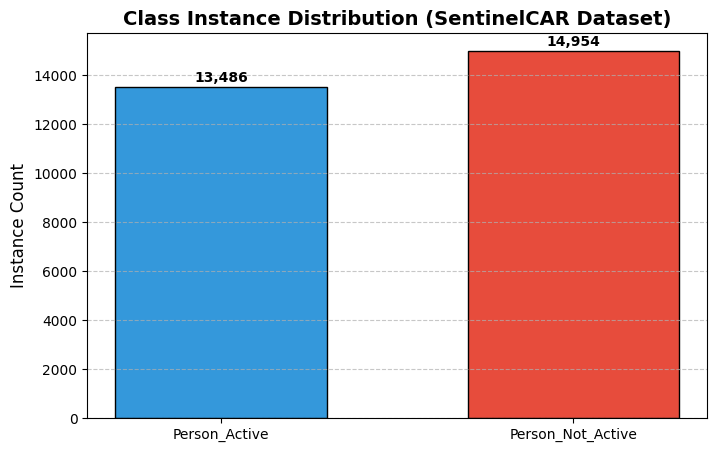

Class Distribution:
  Person_Active (Class 0): 13486 instances (47.42%)
  Person_Not_Active (Class 1): 14954 instances (52.58%)


In [3]:
import matplotlib.pyplot as plt
import collections

class_counts = collections.defaultdict(int)
boxes_per_image = []

for lbl_file in label_files:
    lbl_path = os.path.join(LABELS_DIR, lbl_file)
    with open(lbl_path, 'r') as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]
        boxes_per_image.append(len(lines))
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                cls = int(parts[0])
                class_counts[cls] += 1

# Class distribution plot
classes = [CLASS_NAMES[c] for c in sorted(class_counts.keys())]
counts = [class_counts[c] for c in sorted(class_counts.keys())]

plt.figure(figsize=(8, 5))
bars = plt.bar(classes, counts, color=['#3498db', '#e74c3c'], edgecolor='black', width=0.6)
plt.title('Class Instance Distribution (SentinelCAR Dataset)', fontsize=14, fontweight='bold')
plt.ylabel('Instance Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.show()

print(f'Class Distribution:')
for c in sorted(class_counts.keys()):
    print(f'  {CLASS_NAMES[c]} (Class {c}): {class_counts[c]} instances ({class_counts[c]/sum(counts)*100:.2f}%)')


### 3.2 Bounding Box Statistics & Size Distribution
In a ceiling-mounted fisheye camera setting, passengers are close to the lens, but relative to the entire 180° field of view, their bounding boxes can range from small to large. Let's analyze bounding box widths, heights, aspect ratios (width/height), and area distributions.


Object Size Proportions (Relative Area):
  Small Objects (< 3% image area): 27923 (98.18%)
  Medium Objects (3%-20% image area): 517 (1.82%)
  Large Objects (>= 20% image area): 0 (0.00%)


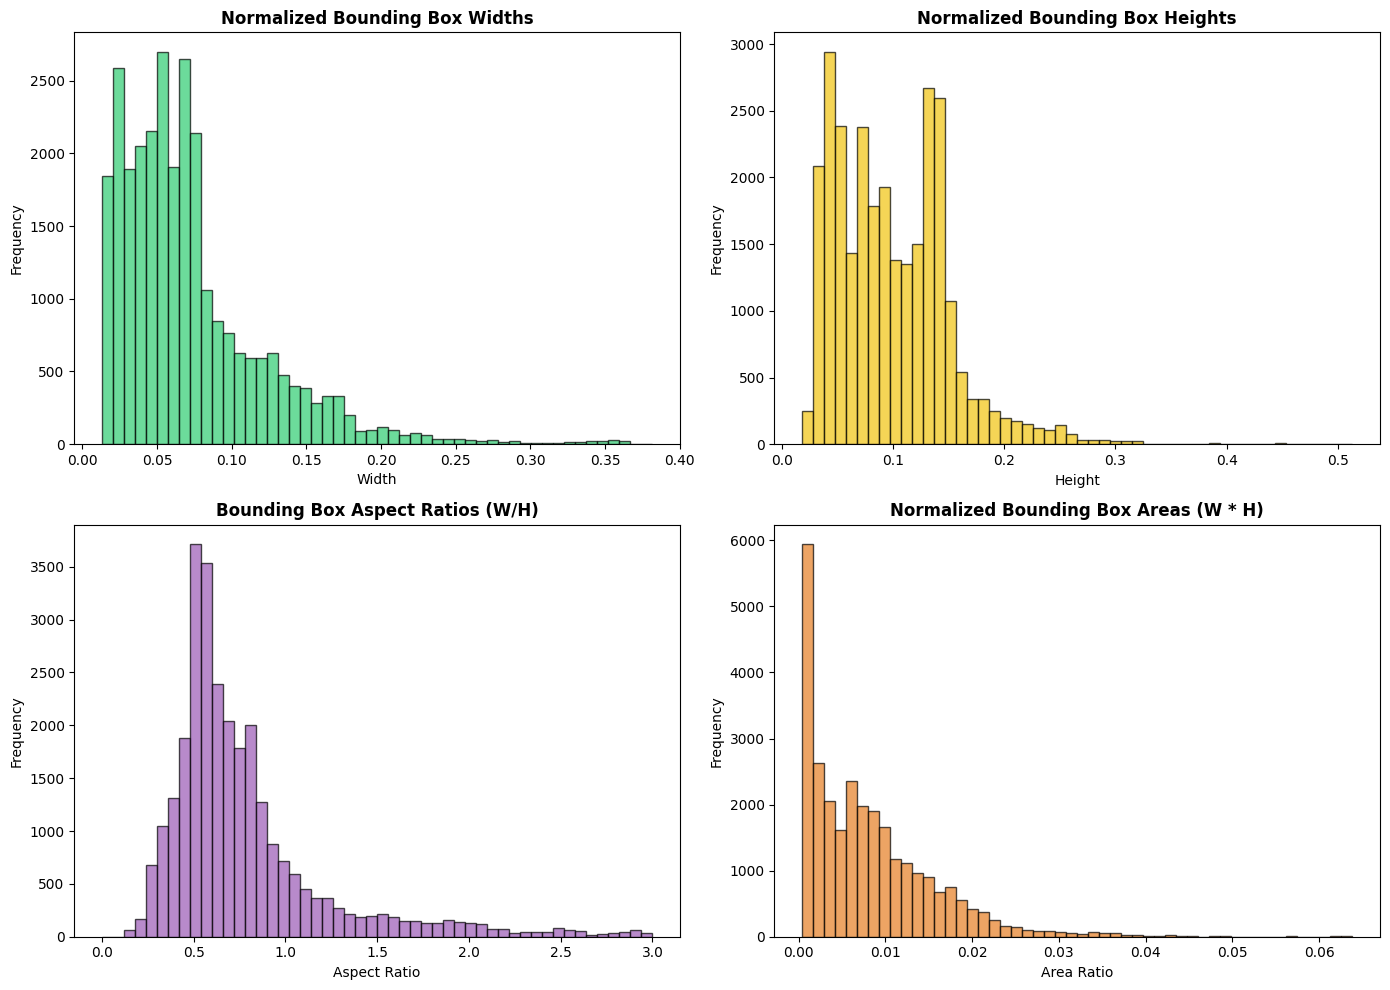

In [4]:
import numpy as np

box_widths = []
box_heights = []
box_areas = []
aspect_ratios = []

for lbl_file in label_files:
    lbl_path = os.path.join(LABELS_DIR, lbl_file)
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                w = float(parts[3])
                h = float(parts[4])
                box_widths.append(w)
                box_heights.append(h)
                box_areas.append(w * h)  # Normalized area relative to full image
                aspect_ratios.append(w / h if h > 0 else 0)

# Categorize objects using COCO relative rules:
# We classify bounding box areas: Small (area < 0.03 of image), Medium (0.03 <= area < 0.2), Large (area >= 0.2)
areas = np.array(box_areas)
small_count = np.sum(areas < 0.03)
medium_count = np.sum((areas >= 0.03) & (areas < 0.2))
large_count = np.sum(areas >= 0.2)
total_boxes = len(areas)

print(f'Object Size Proportions (Relative Area):')
print(f'  Small Objects (< 3% image area): {small_count} ({small_count/total_boxes*100:.2f}%)')
print(f'  Medium Objects (3%-20% image area): {medium_count} ({medium_count/total_boxes*100:.2f}%)')
print(f'  Large Objects (>= 20% image area): {large_count} ({large_count/total_boxes*100:.2f}%)')

# Plot box distribution metrics
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
axs[0, 0].hist(box_widths, bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axs[0, 0].set_title('Normalized Bounding Box Widths', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Width')
axs[0, 0].set_ylabel('Frequency')

# Height distribution
axs[0, 1].hist(box_heights, bins=50, color='#f1c40f', edgecolor='black', alpha=0.7)
axs[0, 1].set_title('Normalized Bounding Box Heights', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Height')
axs[0, 1].set_ylabel('Frequency')

# Aspect ratio distribution
axs[1, 0].hist(aspect_ratios, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7, range=(0, 3))
axs[1, 0].set_title('Bounding Box Aspect Ratios (W/H)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Aspect Ratio')
axs[1, 0].set_ylabel('Frequency')

# Area distribution
axs[1, 1].hist(box_areas, bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
axs[1, 1].set_title('Normalized Bounding Box Areas (W * H)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Area Ratio')
axs[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### 3.3 Visualizing Sample Annotated Images
Let's overlay bounding boxes on a grid of sample images to confirm label indexing and check density patterns.


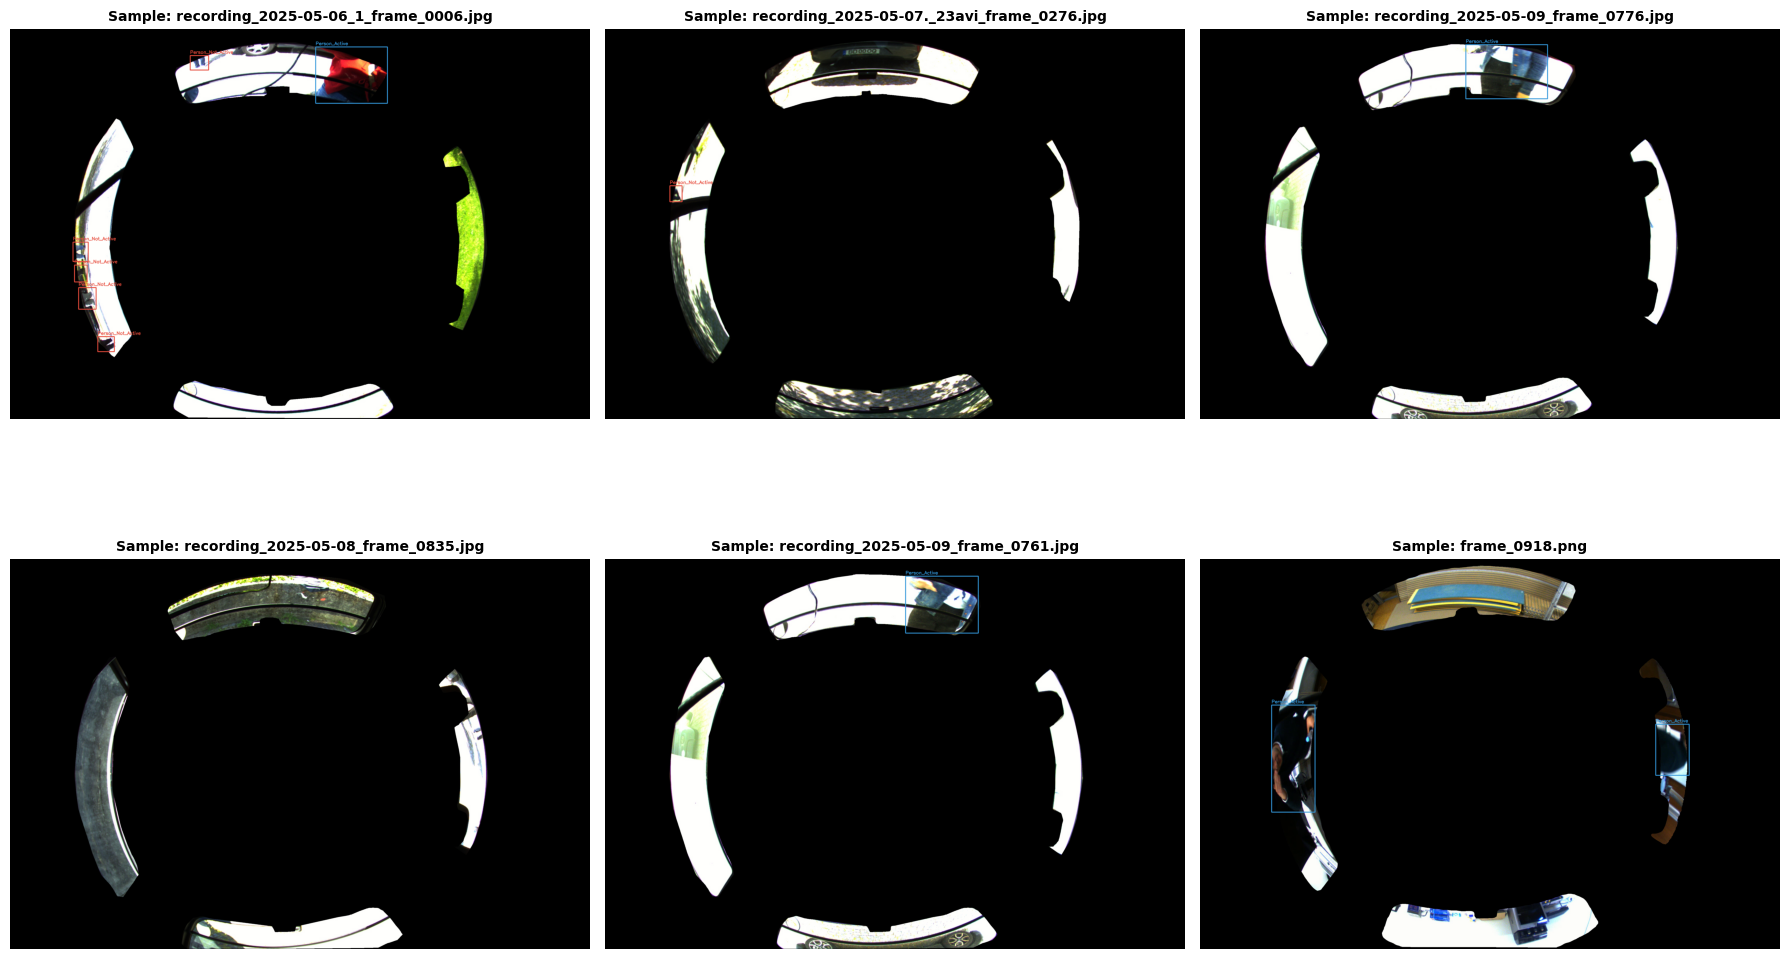

In [5]:
import cv2
import random

def draw_yolo_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if not os.path.exists(label_path):
        return img
        
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                x_c, y_c, box_w, box_h = map(float, parts[1:5])
                
                # Denormalize coordinates
                xmin = int((x_c - box_w/2) * w)
                ymin = int((y_c - box_h/2) * h)
                xmax = int((x_c + box_w/2) * w)
                ymax = int((y_c + box_h/2) * h)
                
                # Choose color based on class id
                color = (52, 152, 219) if cls_id == 0 else (231, 76, 60) # Blue for Active, Red for Inactive
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 3)
                label_text = f'{CLASS_NAMES[cls_id]}'
                cv2.putText(img, label_text, (xmin, max(0, ymin - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return img

# Select a few random files to plot
sample_files = random.sample(image_files, min(6, len(image_files)))

fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.ravel()

for idx, img_file in enumerate(sample_files):
    img_path = os.path.join(IMAGES_DIR, img_file)
    base = os.path.splitext(img_file)[0]
    lbl_path = os.path.join(LABELS_DIR, base + '.txt')
    
    annotated_img = draw_yolo_boxes(img_path, lbl_path)
    axs[idx].imshow(annotated_img)
    axs[idx].set_title(f'Sample: {img_file}', fontsize=10, fontweight='bold')
    axs[idx].axis('off')

plt.tight_layout()
plt.show()


## 4. DATA LEAKAGE PREVENTION & STRATIFIED SPLITTING
Automotive camera frames captured consecutively in a short interval suffer from high similarity. If consecutive frames from the same recording sequence end up in different splits, the validation metrics will be falsely inflated. 

### 4.1 Sequence Extraction & Stratified Greedy Search
We group the filenames into unique sequence IDs. We then use a randomized greedy optimization search to partition these sequence groups into Train (80%), Val (10%), and Test (10%) splits while preserving the target class ratios as closely as possible.


In [6]:
def get_sequence_id(filename):
    base = os.path.splitext(filename)[0]
    # Match date-time pattern or video prefix
    # e.g., recording_2025-05-06_10_frame_0000.jpg -> recording_2025-05-06_10
    # e.g., 17_09_2024__18.28.28.407.png -> 17_09_2024__18.28
    if 'frame_' in base:
        parts = base.split('frame_')
        prefix = parts[0]
        if prefix.endswith('_'):
            prefix = prefix[:-1]
        if not prefix:
            prefix = 'frame_sequence'
        return prefix
    if '__' in base:
        parts = base.split('__')
        date_part = parts[0]
        time_part = parts[1]
        time_prefix = '.'.join(time_part.split('.')[:2])
        return f'{date_part}__{time_prefix}'
    return 'unknown'

# Step 1: Collect stats per sequence
sequence_stats = {}

for img in image_files:
    seq_id = get_sequence_id(img)
    if seq_id not in sequence_stats:
        sequence_stats[seq_id] = {'frames': [], 'class_0': 0, 'class_1': 0}
    
    sequence_stats[seq_id]['frames'].append(img)
    
    base = os.path.splitext(img)[0]
    label_path = os.path.join(LABELS_DIR, base + '.txt')
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    if cls == 0:
                        sequence_stats[seq_id]['class_0'] += 1
                    elif cls == 1:
                        sequence_stats[seq_id]['class_1'] += 1

sequences = list(sequence_stats.items())
total_frames = len(image_files)
total_c0 = sum(s[1]['class_0'] for s in sequences)
total_c1 = sum(s[1]['class_1'] for s in sequences)
target_ratio = total_c0 / (total_c0 + total_c1) if (total_c0 + total_c1) > 0 else 0.5

print(f'Extracted {len(sequences)} unique sequences.')

# Step 2: Randomized Greedy Optimization for Partitioning
random.seed(SEED)
best_score = float('inf')
best_partition = None

for _ in range(50000):
    shuffled_seqs = list(sequences)
    random.shuffle(shuffled_seqs)
    
    tr_seqs, val_seqs, te_seqs = [], [], []
    tr_f, val_f, te_f = 0, 0, 0
    
    for seq_id, stats in shuffled_seqs:
        f_count = len(stats['frames'])
        p_val = val_f / total_frames
        p_te = te_f / total_frames
        
        if p_val < SPLIT_RATIO['val']:
            val_seqs.append((seq_id, stats))
            val_f += f_count
        elif p_te < SPLIT_RATIO['test']:
            te_seqs.append((seq_id, stats))
            te_f += f_count
        else:
            tr_seqs.append((seq_id, stats))
            tr_f += f_count
            
    # Calculate scores (squared distance from split targets and class ratios)
    r_tr, r_val, r_te = tr_f/total_frames, val_f/total_frames, te_f/total_frames
    
    tr_c0 = sum(s[1]['class_0'] for s in tr_seqs)
    tr_c1 = sum(s[1]['class_1'] for s in tr_seqs)
    val_c0 = sum(s[1]['class_0'] for s in val_seqs)
    val_c1 = sum(s[1]['class_1'] for s in val_seqs)
    te_c0 = sum(s[1]['class_0'] for s in te_seqs)
    te_c1 = sum(s[1]['class_1'] for s in te_seqs)
    
    ratio_tr = tr_c0 / (tr_c0 + tr_c1) if (tr_c0 + tr_c1) > 0 else 0
    ratio_val = val_c0 / (val_c0 + val_c1) if (val_c0 + val_c1) > 0 else 0
    ratio_te = te_c0 / (te_c0 + te_c1) if (te_c0 + te_c1) > 0 else 0
    
    score = (
        (r_tr - SPLIT_RATIO['train'])**2 + 
        (r_val - SPLIT_RATIO['val'])**2 + 
        (r_te - SPLIT_RATIO['test'])**2 + 
        (ratio_tr - target_ratio)**2 + 
        (ratio_val - target_ratio)**2 + 
        (ratio_te - target_ratio)**2
    )
    
    if score < best_score:
        best_score = score
        best_partition = (tr_seqs, val_seqs, te_seqs)

train_seqs, val_seqs, test_seqs = best_partition

tr_f = sum(len(s[1]['frames']) for s in train_seqs)
val_f = sum(len(s[1]['frames']) for s in val_seqs)
te_f = sum(len(s[1]['frames']) for s in test_seqs)

print('Best Sequence Splits Found:')
print(f'  Train: {tr_f} frames ({tr_f/total_frames*100:.2f}%)')
print(f'  Val:   {val_f} frames ({val_f/total_frames*100:.2f}%)')
print(f'  Test:  {te_f} frames ({te_f/total_frames*100:.2f}%)')


Extracted 38 unique sequences.
Best Sequence Splits Found:
  Train: 14285 frames (78.03%)
  Val:   1834 frames (10.02%)
  Test:  2189 frames (11.96%)


### 4.2 Copying Files to Split Directories
We create the target YOLO split folder structures and write files accordingly. This creates train/val/test directories.


In [7]:
import shutil

splits = {
    'train': train_seqs,
    'val': val_seqs,
    'test': test_seqs
}

for split, seq_list in splits.items():
    split_img_dir = os.path.join(OUTPUT_DIR, split, 'images')
    split_lbl_dir = os.path.join(OUTPUT_DIR, split, 'labels')
    os.makedirs(split_img_dir, exist_ok=True)
    os.makedirs(split_lbl_dir, exist_ok=True)
    
    print(f'Copying {split} files to {split_img_dir}...')
    for _, stats in seq_list:
        for f in stats['frames']:
            # Copy image
            shutil.copy2(os.path.join(IMAGES_DIR, f), os.path.join(split_img_dir, f))
            # Copy label if exists
            base = os.path.splitext(f)[0]
            lbl = base + '.txt'
            if os.path.exists(os.path.join(LABELS_DIR, lbl)):
                shutil.copy2(os.path.join(LABELS_DIR, lbl), os.path.join(split_lbl_dir, lbl))

print('Dataset successfully split and written.')


Copying train files to /kaggle/working/SentiCAR_dataset_yolo_OD/train/images...
Copying val files to /kaggle/working/SentiCAR_dataset_yolo_OD/val/images...
Copying test files to /kaggle/working/SentiCAR_dataset_yolo_OD/test/images...
Dataset successfully split and written.


## 5. DATA AUGMENTATION WITH ALBUMENTATIONS

Surveillance inside vehicle cabins deals with severe challenges: dynamic lighting, headlight glare, blur from motion/camera vibrations, and radial fisheye distortions. 
We construct an **Albumentations** pipeline targeting these specific issues:
1. **Photometric Transforms:**
   - `RandomBrightnessContrast` (simulating headlight glare / outdoor lighting change)
   - `GaussianBlur` (simulating windshield fog or lens condensation)
   - `GaussNoise` (simulating sensor static during night/low-light)
2. **Geometric Transforms:**
   - `HorizontalFlip` (retains relative layout, valid mirror scenario)
   - `ShiftScaleRotate` (simulates camera mount vibrations or rotation)
   - **EXCLUDED:** `VerticalFlip`. A passenger inside a vehicle is always vertically oriented relative to the ceiling-mounted camera. Training with vertical flips introduces physically impossible poses, causing optimization confusion.
3. **Resizing:** Resize to `640x640` while updating bounding box locations.


In [8]:
import albumentations as A

# Augmentation Pipeline using Albumentations
train_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print('Albumentations augmentation pipeline defined.')


Albumentations augmentation pipeline defined.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_58/1164190464.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


## 6. INPUT PIPELINE VERIFICATION (VISUALIZATION)
We visualize an image before and after applying the augmentation pipeline to ensure the bounding box transformation maintains alignment.


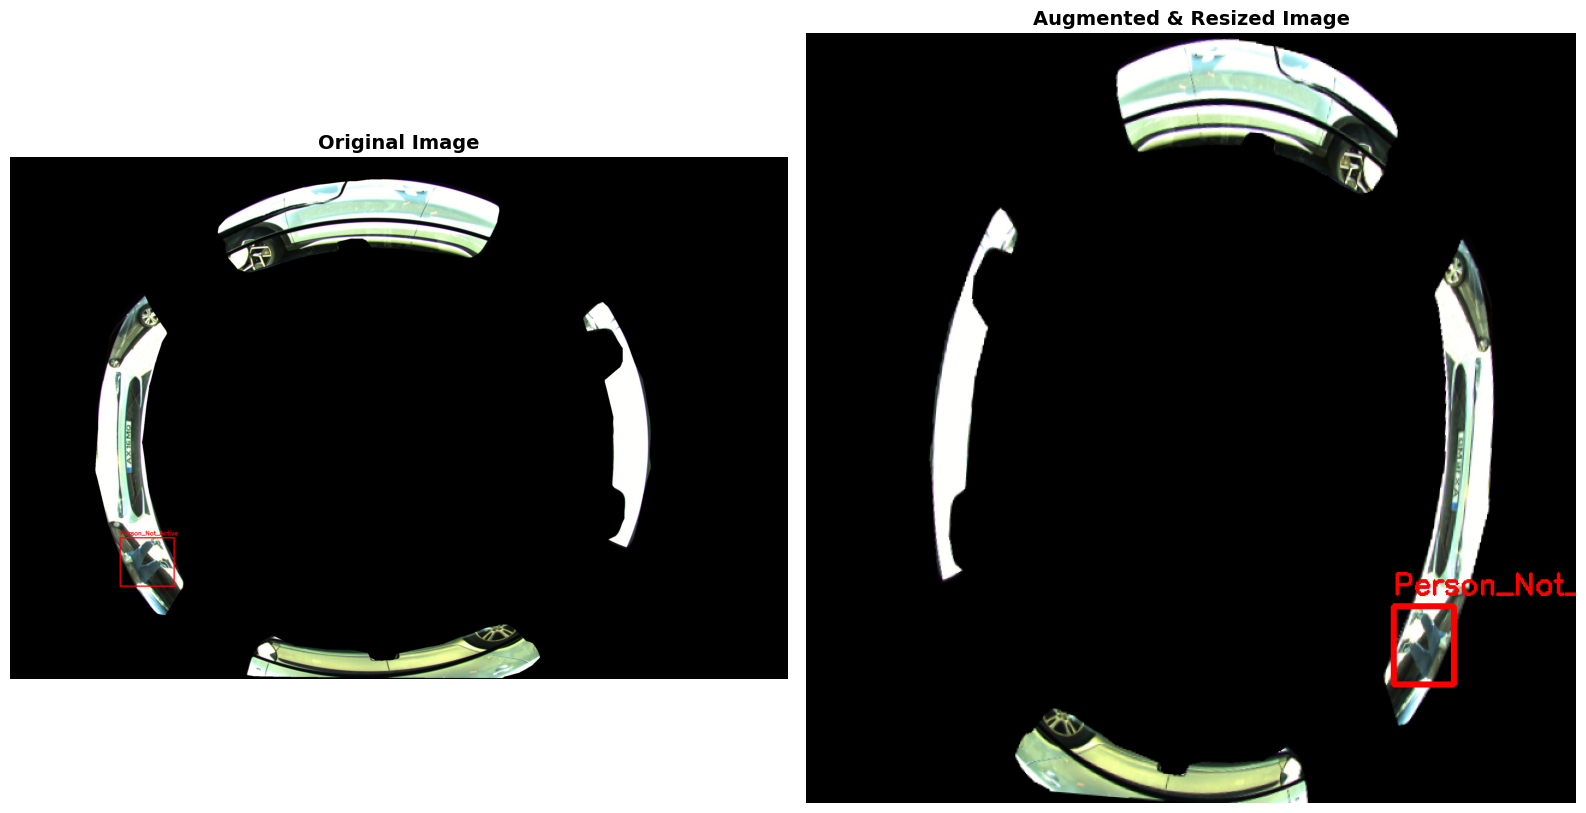

In [9]:
def load_yolo_annotations(lbl_path):
    bboxes = []
    class_labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    c = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                    bboxes.append([x, y, w, h])
                    class_labels.append(c)
    return bboxes, class_labels

def draw_albumentations_boxes(img, bboxes, labels):
    img_copy = img.copy()
    h, w, _ = img_copy.shape
    for box, label in zip(bboxes, labels):
        x_c, y_c, box_w, box_h = box
        xmin = int((x_c - box_w/2) * w)
        ymin = int((y_c - box_h/2) * h)
        xmax = int((x_c + box_w/2) * w)
        ymax = int((y_c + box_h/2) * h)
        color = (0, 255, 0) if label == 0 else (255, 0, 0)
        cv2.rectangle(img_copy, (xmin, ymin), (xmax, ymax), color, 3)
        cv2.putText(img_copy, CLASS_NAMES[label], (xmin, max(0, ymin - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return img_copy

# Pick a sample
sample_file = random.choice(image_files)
sample_base = os.path.splitext(sample_file)[0]
img_path = os.path.join(IMAGES_DIR, sample_file)
lbl_path = os.path.join(LABELS_DIR, sample_base + '.txt')

# Load image & label
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
bboxes, labels = load_yolo_annotations(lbl_path)

# Apply transform
transformed = train_transform(image=img, bboxes=bboxes, class_labels=labels)
trans_img = transformed['image']
trans_bboxes = transformed['bboxes']
trans_labels = transformed['class_labels']

# Plot original vs augmented side-by-side
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

orig_drawn = draw_albumentations_boxes(img, bboxes, labels)
axs[0].imshow(orig_drawn)
axs[0].set_title('Original Image', fontsize=14, fontweight='bold')
axs[0].axis('off')

aug_drawn = draw_albumentations_boxes(trans_img, trans_bboxes, trans_labels)
axs[1].imshow(aug_drawn)
axs[1].set_title('Augmented & Resized Image', fontsize=14, fontweight='bold')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 7. WRITTEN SUMMARY: DATASET CHARACTERISTICS
### Key Insights for Modeling:
1. **Fisheye Distortion Geometry:** Bounding box sizes are heavily dependent on proximity to the camera. The center of the frame has high pixel density, while peripheral areas compress objects radially. Models must be scale-robust (small-target focus).
2. **Dynamic Illumination & Glare:** Surviving cabin shadows and outdoor day-night glare means brightness jitter during training is critical.
3. **Zero Bounding Box Leakage:** By partitioning sequences rather than individual frames, we guarantee that models cannot copy background metadata across splits, ensuring robust validation metrics.


In [10]:
import shutil

shutil.make_archive('SentiCAR_dataset_yolo_OD', 'zip', '/kaggle/working/SentiCAR_dataset_yolo_OD')
print("Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.")

Zip file created successfully. You can now download 'yolo_training_results.zip' from the right panel under /kaggle/working.
